<a href="https://colab.research.google.com/github/takaakisasaki/DepMap-based-in-silico-screening-of-synthetic-lethal-paralogs/blob/main/IMPDH1_PROTAC_Docking_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 IMPDH1 vs IMPDH2: Selectivity Analysis

## Project Overview
- **Target**: IMPDH1 (Inosine Monophosphate Dehydrogenase 1)
- **Comparison**: IMPDH2 selectivity for PROTAC design
- **Goal**: Evaluate PROTAC selectivity between IMPDH1 and IMPDH2

### Why Selectivity Matters
| Isoform | Expression | Targeting Goal |
|---------|------------|----------------|
| IMPDH1 | Heart, Brain, Retina | **Avoid** (toxicity) |
| IMPDH2 | Proliferating cells, Cancer | **Target** (therapeutic) |

---

## 1. Environment Setup

In [1]:
# Install required packages
!pip install -q rdkit
!pip install -q gemmi
!pip install -q meeko
!pip install -q vina
!pip install -q py3Dmol
!pip install -q biopython

print("✓ All packages installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.7 MB/s eta 0:00:00
✓ All packages installed


In [2]:
# Import libraries
import os
import json
import requests
import numpy as np
from datetime import datetime

# RDKit
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, Descriptors

# 3D Visualization
import py3Dmol

print("✓ Basic imports successful")
print(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

✓ Basic imports successful
Date: 2026-01-29 04:37


In [3]:
# Docking tools
try:
    from meeko import MoleculePreparation
    from vina import Vina
    print("✓ Meeko and Vina imported")
    DOCKING_AVAILABLE = True
except ImportError as e:
    print(f"⚠ Docking tools not available: {e}")
    DOCKING_AVAILABLE = False

✓ Meeko and Vina imported


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create project directory
PROJECT_DIR = "/content/drive/MyDrive/2026/PROTAC_glue/IMPDH1_selectivity"
os.makedirs(f"{PROJECT_DIR}/structures", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/docking/ligands", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/docking/poses", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/figures", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/comparison", exist_ok=True)

print(f"✓ Project directory: {PROJECT_DIR}")

Mounted at /content/drive
✓ Project directory: /content/drive/MyDrive/2026/PROTAC_glue/IMPDH1_selectivity


---
## 2. IMPDH1 Structure Download & Analysis

In [5]:
# Download IMPDH1 crystal structure (PDB: 1JCN - with MPA bound)
PDB_ID = "1JCN"
url = f"https://files.rcsb.org/download/{PDB_ID}.pdb"

print(f"Downloading {PDB_ID}...")
response = requests.get(url, timeout=30)
pdb_text = response.text

# Save
pdb_path = f"{PROJECT_DIR}/structures/{PDB_ID}.pdb"
with open(pdb_path, 'w') as f:
    f.write(pdb_text)

print(f"✓ Downloaded: {pdb_path}")

# Structure info
n_atoms = pdb_text.count('\nATOM')
chains = set()
for line in pdb_text.split('\n'):
    if line.startswith('ATOM'):
        chains.add(line[21])

print(f"\n[Structure Info]")
print(f"  PDB ID: {PDB_ID}")
print(f"  Protein: IMPDH1 (Human)")
print(f"  UniProt: P20839")
print(f"  Atoms: {n_atoms}")
print(f"  Chains: {sorted(chains)}")

✓ Downloaded: /content/drive/MyDrive/2026/PROTAC_glue/IMPDH1_selectivity/structures/1JCN.pdb

[Structure Info]
  PDB ID: 1JCN
  Protein: IMPDH1 (Human)
  UniProt: P20839
  Atoms: 5878
  Chains: ['A', 'B']


In [6]:
# Analyze ligands in structure
print("[Ligands in IMPDH1 structure]")
print("-" * 50)

hetatm_info = {}
for line in pdb_text.split('\n'):
    if line.startswith('HETATM'):
        res_name = line[17:20].strip()
        chain = line[21]
        if res_name not in ['HOH']:
            key = f"{res_name}_{chain}"
            if key not in hetatm_info:
                hetatm_info[key] = []
            try:
                x = float(line[30:38])
                y = float(line[38:46])
                z = float(line[46:54])
                hetatm_info[key].append([x, y, z])
            except:
                pass

for key, coords in hetatm_info.items():
    center = np.mean(coords, axis=0)
    print(f"  {key}: center = ({center[0]:.1f}, {center[1]:.1f}, {center[2]:.1f}), {len(coords)} atoms")

[Ligands in IMPDH1 structure]
--------------------------------------------------
  CPR_A: center = (-11.4, 22.0, 55.1), 22 atoms
  CPR_B: center = (22.0, -11.4, 1.0), 22 atoms


In [7]:
# Extract chain A for docking
chain_a_lines = []
for line in pdb_text.split('\n'):
    if line.startswith('ATOM') and line[21] == 'A':
        chain_a_lines.append(line)
    elif line.startswith('END'):
        chain_a_lines.append(line)

protein_pdb = f"{PROJECT_DIR}/structures/IMPDH1_chainA.pdb"
with open(protein_pdb, 'w') as f:
    f.write('\n'.join(chain_a_lines))

print(f"✓ Extracted Chain A: {protein_pdb}")
print(f"  Atoms: {len([l for l in chain_a_lines if l.startswith('ATOM')])}")

✓ Extracted Chain A: /content/drive/MyDrive/2026/PROTAC_glue/IMPDH1_selectivity/structures/IMPDH1_chainA.pdb
  Atoms: 2939


---
## 3. Identify Binding Site (from MPA position)

In [8]:
# Find MPA (Mycophenolic acid) position for binding site
# In 1JCN, the ligand code may be MPA or similar

mpa_coords = []
for line in pdb_text.split('\n'):
    if line.startswith('HETATM') and line[21] == 'A':
        res_name = line[17:20].strip()
        # Look for MPA, MOA, or similar
        if res_name in ['MPA', 'MOA', 'MYC', 'MPD']:
            try:
                x = float(line[30:38])
                y = float(line[38:46])
                z = float(line[46:54])
                mpa_coords.append([x, y, z])
            except:
                pass

if mpa_coords:
    BINDING_SITE_CENTER = np.mean(mpa_coords, axis=0)
    print(f"✓ Binding site center (from ligand): {BINDING_SITE_CENTER}")
else:
    # Use approximate center based on known IMPDH binding site
    # This may need adjustment based on actual structure
    print("⚠ MPA not found, searching for other ligands...")
    # Try to find any ligand in chain A
    for key, coords in hetatm_info.items():
        if '_A' in key and 'HOH' not in key:
            BINDING_SITE_CENTER = np.mean(coords, axis=0)
            print(f"✓ Using {key} as reference: {BINDING_SITE_CENTER}")
            break

# Define box size
BOX_SIZE = [25, 25, 25]  # Angstroms
print(f"  Box size: {BOX_SIZE}")

⚠ MPA not found, searching for other ligands...
✓ Using CPR_A as reference: [-11.35854545  21.99177273  55.05677273]
  Box size: [25, 25, 25]


---
## 4. Prepare Ligands (Same as IMPDH2)

In [9]:
# Define ligands - same as IMPDH2 for fair comparison
MPA_SMILES = 'COc1c(C)c2COC(=O)c2c(O)c1C/C=C(\\C)/CCC(=O)O'

# Ligands to test
ligands = {
    'MPA': MPA_SMILES,
    'MPA_amide': 'COc1c(C)c2COC(=O)c2c(O)c1C/C=C(\\C)/CCC(=O)N',
    'MPA_PEG2': 'COc1c(C)c2COC(=O)c2c(O)c1C/C=C(\\C)/CCC(=O)NCCOCCO',
    'MPA_PEG4': 'COc1c(C)c2COC(=O)c2c(O)c1C/C=C(\\C)/CCC(=O)NCCOCCOCCOCCOCCN',
}

print("[Ligands for docking]")
for name, smi in ligands.items():
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mw = Descriptors.MolWt(mol)
        print(f"  {name}: MW={mw:.1f}")

[Ligands for docking]
  MPA: MW=320.3
  MPA_amide: MW=319.4
  MPA_PEG2: MW=407.5
  MPA_PEG4: MW=538.6


In [10]:
# Prepare ligand 3D structures
def prepare_ligand(smiles, name, output_dir):
    """Generate 3D structure and PDBQT for docking"""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)

    # Save SDF
    sdf_path = f"{output_dir}/{name}.sdf"
    writer = Chem.SDWriter(sdf_path)
    writer.write(mol)
    writer.close()

    # Convert to PDBQT using Meeko
    try:
        preparator = MoleculePreparation()
        mol_setup = preparator.prepare(mol)
        pdbqt_string = preparator.write_pdbqt_string()

        pdbqt_path = f"{output_dir}/{name}.pdbqt"
        with open(pdbqt_path, 'w') as f:
            f.write(pdbqt_string)

        return pdbqt_path
    except Exception as e:
        print(f"  Warning: Meeko failed for {name}: {e}")
        return None

print("Preparing ligands...")
ligand_files = {}
for name, smi in ligands.items():
    pdbqt = prepare_ligand(smi, name, f"{PROJECT_DIR}/docking/ligands")
    if pdbqt:
        ligand_files[name] = pdbqt
        print(f"  ✓ {name}")
    else:
        print(f"  ✗ {name} failed")

Preparing ligands...
  ✓ MPA


/usr/local/lib/python3.12/dist-packages/meeko/preparation.py:693: DeprecationWarning: MoleculePreparation.write_pdbqt_string() is deprecated in Meeko v0.5. Pass the MoleculeSetup instance to PDBQTWriterLegacy.write_string(). MoleculePreparation.prepare() returns a list of MoleculeSetup instances.
  warnings.warn(msg, DeprecationWarning)
/usr/local/lib/python3.12/dist-packages/meeko/preparation.py:467: DeprecationWarning: MoleculePreparation.setup is deprecated in Meeko v0.5. MoleculePreparation.prepare() returns a list of MoleculeSetup instances.
  warnings.warn(msg, DeprecationWarning)


  ✓ MPA_amide
  ✓ MPA_PEG2
  ✓ MPA_PEG4


---
## 5. Prepare Receptor

In [11]:
# Prepare receptor PDBQT
def prepare_receptor_simple(pdb_path, output_path):
    """Simple PDB to PDBQT conversion"""
    with open(pdb_path, 'r') as f:
        lines = f.readlines()

    pdbqt_lines = []
    for line in lines:
        if line.startswith('ATOM'):
            atom_name = line[12:16].strip()

            # Assign AutoDock atom types
            if atom_name.startswith('C'):
                ad_type = 'C'
            elif atom_name.startswith('N'):
                ad_type = 'N'
            elif atom_name.startswith('O'):
                ad_type = 'OA'
            elif atom_name.startswith('S'):
                ad_type = 'SA'
            elif atom_name.startswith('H'):
                ad_type = 'HD'
            else:
                ad_type = 'C'

            new_line = line[:77].ljust(77) + f" {ad_type:>2}\n"
            pdbqt_lines.append(new_line)

    with open(output_path, 'w') as f:
        f.writelines(pdbqt_lines)

    return output_path

receptor_pdbqt = f"{PROJECT_DIR}/structures/IMPDH1_receptor.pdbqt"
prepare_receptor_simple(protein_pdb, receptor_pdbqt)
print(f"✓ Receptor prepared: {receptor_pdbqt}")

✓ Receptor prepared: /content/drive/MyDrive/2026/PROTAC_glue/IMPDH1_selectivity/structures/IMPDH1_receptor.pdbqt


---
## 6. Run Docking

In [12]:
# Docking function
def run_docking(receptor_pdbqt, ligand_pdbqt, center, box_size, output_prefix):
    """Run AutoDock Vina docking"""
    v = Vina(sf_name='vina')
    v.set_receptor(receptor_pdbqt)
    v.set_ligand_from_file(ligand_pdbqt)
    v.compute_vina_maps(center=center, box_size=box_size)

    v.dock(exhaustiveness=32, n_poses=10)

    # Get scores
    energies = v.energies()

    # Save best pose
    output_pdbqt = f"{output_prefix}_docked.pdbqt"
    v.write_poses(output_pdbqt, n_poses=5, overwrite=True)

    return energies[0][0], output_pdbqt  # Return best score

In [13]:
# Run docking for all ligands
print("\n" + "="*60)
print("Running IMPDH1 Docking")
print("="*60)

results_impdh1 = []

if DOCKING_AVAILABLE:
    for name, pdbqt_path in ligand_files.items():
        print(f"\nDocking {name}...")
        try:
            output_prefix = f"{PROJECT_DIR}/docking/poses/{name}"
            score, pose_file = run_docking(
                receptor_pdbqt,
                pdbqt_path,
                center=BINDING_SITE_CENTER.tolist(),
                box_size=BOX_SIZE,
                output_prefix=output_prefix
            )
            results_impdh1.append({
                'name': name,
                'affinity': score,
                'pose_file': pose_file
            })
            print(f"  ✓ {name}: {score:.2f} kcal/mol")
        except Exception as e:
            print(f"  ✗ {name}: {e}")

    # Sort by affinity
    results_impdh1.sort(key=lambda x: x['affinity'])
else:
    print("⚠ Docking not available")


Running IMPDH1 Docking

Docking MPA...
  ✓ MPA: -6.71 kcal/mol

Docking MPA_amide...
  ✓ MPA_amide: -6.79 kcal/mol

Docking MPA_PEG2...
  ✓ MPA_PEG2: -6.39 kcal/mol

Docking MPA_PEG4...
  ✓ MPA_PEG4: -6.32 kcal/mol


In [14]:
# Display IMPDH1 docking results
print("\n" + "="*60)
print("IMPDH1 Docking Results")
print("="*60)
print(f"{'Ligand':<15} {'Affinity (kcal/mol)':<20}")
print("-"*35)

for r in results_impdh1:
    print(f"{r['name']:<15} {r['affinity']:<20.2f}")


IMPDH1 Docking Results
Ligand          Affinity (kcal/mol) 
-----------------------------------
MPA_amide       -6.79               
MPA             -6.71               
MPA_PEG2        -6.39               
MPA_PEG4        -6.32               


---
## 7. Load IMPDH2 Results for Comparison

In [15]:
# Load IMPDH2 results from previous docking
IMPDH2_DIR = "/content/drive/MyDrive/2026/PROTAC_glue/IMPDH2_PROTAC"

try:
    with open(f"{IMPDH2_DIR}/IMPDH2_PROTAC_results.json", 'r') as f:
        impdh2_data = json.load(f)

    results_impdh2 = impdh2_data.get('docking_results', [])
    print("✓ Loaded IMPDH2 results")
    print(f"  {len(results_impdh2)} ligands")
except FileNotFoundError:
    print("⚠ IMPDH2 results not found. Using reference values.")
    # Reference values from your previous docking
    results_impdh2 = [
        {'name': 'MPA_amide', 'affinity': -7.79},
        {'name': 'MPA', 'affinity': -7.72},
        {'name': 'MPA_PEG2', 'affinity': -7.22},
        {'name': 'MPA_PEG4', 'affinity': -6.54},
    ]

✓ Loaded IMPDH2 results
  4 ligands


---
## 8. Selectivity Analysis

In [16]:
# Compare IMPDH1 vs IMPDH2
print("\n" + "="*70)
print("SELECTIVITY ANALYSIS: IMPDH1 vs IMPDH2")
print("="*70)

print(f"\n{'Ligand':<15} {'IMPDH1':<12} {'IMPDH2':<12} {'ΔΔG':<10} {'Selectivity'}")
print("-"*65)

comparison_data = []

for r1 in results_impdh1:
    name = r1['name']
    aff1 = r1['affinity']

    # Find matching IMPDH2 result
    aff2 = None
    for r2 in results_impdh2:
        if r2['name'] == name:
            aff2 = r2['affinity']
            break

    if aff2 is not None:
        delta_dg = aff1 - aff2  # Positive = prefers IMPDH2

        if delta_dg > 0.5:
            selectivity = "IMPDH2 selective ✓"
        elif delta_dg < -0.5:
            selectivity = "IMPDH1 selective ✗"
        else:
            selectivity = "Non-selective"

        comparison_data.append({
            'name': name,
            'impdh1': aff1,
            'impdh2': aff2,
            'delta_dg': delta_dg,
            'selectivity': selectivity
        })

        print(f"{name:<15} {aff1:<12.2f} {aff2:<12.2f} {delta_dg:<+10.2f} {selectivity}")


SELECTIVITY ANALYSIS: IMPDH1 vs IMPDH2

Ligand          IMPDH1       IMPDH2       ΔΔG        Selectivity
-----------------------------------------------------------------
MPA_amide       -6.79        -7.79        +1.01      IMPDH2 selective ✓
MPA             -6.71        -7.72        +1.02      IMPDH2 selective ✓
MPA_PEG2        -6.39        -7.22        +0.83      IMPDH2 selective ✓
MPA_PEG4        -6.32        -6.54        +0.23      Non-selective


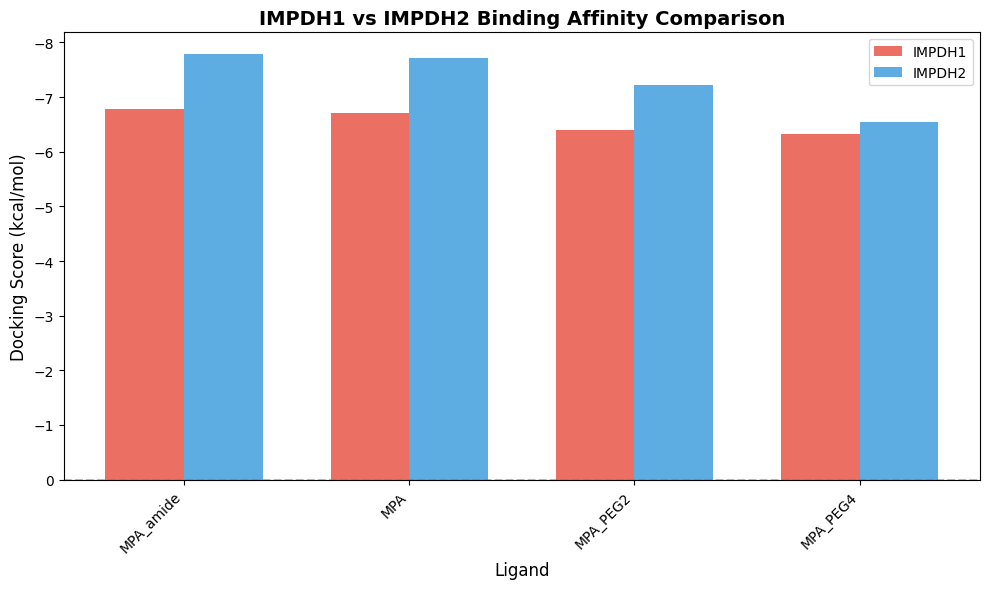


✓ Saved: /content/drive/MyDrive/2026/PROTAC_glue/IMPDH1_selectivity/figures/selectivity_comparison.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
# Visualization: Bar chart comparison
import matplotlib.pyplot as plt

if comparison_data:
    fig, ax = plt.subplots(figsize=(10, 6))

    names = [d['name'] for d in comparison_data]
    impdh1_scores = [d['impdh1'] for d in comparison_data]
    impdh2_scores = [d['impdh2'] for d in comparison_data]

    x = np.arange(len(names))
    width = 0.35

    bars1 = ax.bar(x - width/2, impdh1_scores, width, label='IMPDH1', color='#E74C3C', alpha=0.8)
    bars2 = ax.bar(x + width/2, impdh2_scores, width, label='IMPDH2', color='#3498DB', alpha=0.8)

    ax.set_ylabel('Docking Score (kcal/mol)', fontsize=12)
    ax.set_xlabel('Ligand', fontsize=12)
    ax.set_title('IMPDH1 vs IMPDH2 Binding Affinity Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.legend()
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

    # More negative = better binding
    ax.invert_yaxis()

    plt.tight_layout()
    plt.savefig(f"{PROJECT_DIR}/figures/selectivity_comparison.png", dpi=300)
    plt.show()

    print(f"\n✓ Saved: {PROJECT_DIR}/figures/selectivity_comparison.png")

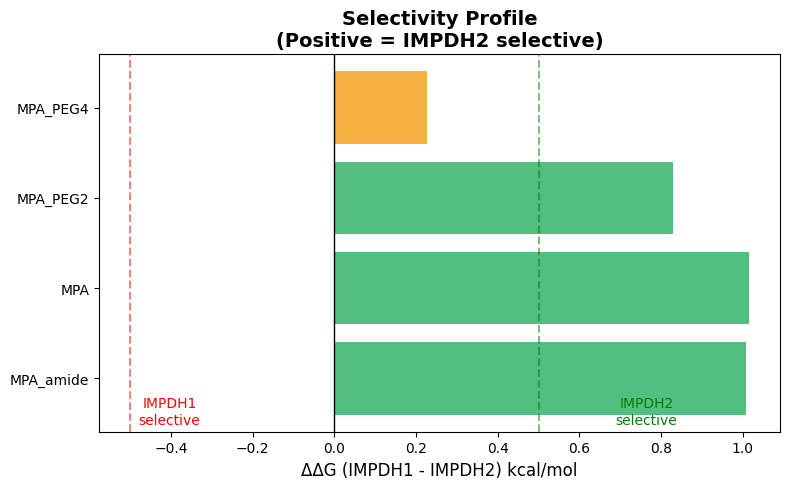


✓ Saved: /content/drive/MyDrive/2026/PROTAC_glue/IMPDH1_selectivity/figures/selectivity_profile.png


In [18]:
# Selectivity ratio visualization
if comparison_data:
    fig, ax = plt.subplots(figsize=(8, 5))

    names = [d['name'] for d in comparison_data]
    delta_dg = [d['delta_dg'] for d in comparison_data]

    colors = ['#27AE60' if d > 0.5 else '#E74C3C' if d < -0.5 else '#F39C12' for d in delta_dg]

    bars = ax.barh(names, delta_dg, color=colors, alpha=0.8)

    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax.axvline(x=0.5, color='green', linestyle='--', alpha=0.5, label='IMPDH2 selective threshold')
    ax.axvline(x=-0.5, color='red', linestyle='--', alpha=0.5, label='IMPDH1 selective threshold')

    ax.set_xlabel('ΔΔG (IMPDH1 - IMPDH2) kcal/mol', fontsize=12)
    ax.set_title('Selectivity Profile\n(Positive = IMPDH2 selective)', fontsize=14, fontweight='bold')

    # Add labels
    ax.text(ax.get_xlim()[1]*0.7, -0.5, 'IMPDH2\nselective', ha='center', fontsize=10, color='green')
    ax.text(ax.get_xlim()[0]*0.7, -0.5, 'IMPDH1\nselective', ha='center', fontsize=10, color='red')

    plt.tight_layout()
    plt.savefig(f"{PROJECT_DIR}/figures/selectivity_profile.png", dpi=300)
    plt.show()

    print(f"\n✓ Saved: {PROJECT_DIR}/figures/selectivity_profile.png")

---
## 9. 3D Visualization

In [19]:
# Visualize best pose in IMPDH1
if results_impdh1:
    best_result = results_impdh1[0]  # Best scoring

    print(f"Visualizing best pose: {best_result['name']} ({best_result['affinity']:.2f} kcal/mol)")

    # Load structures
    with open(protein_pdb, 'r') as f:
        protein_pdb_text = f.read()

    with open(best_result['pose_file'], 'r') as f:
        ligand_pdb_text = f.read()

    # Create viewer
    viewer = py3Dmol.view(width=800, height=600)

    # Add protein
    viewer.addModel(protein_pdb_text, 'pdb')
    viewer.setStyle({'model': 0}, {'cartoon': {'color': 'spectrum'}})

    # Add ligand
    viewer.addModel(ligand_pdb_text, 'pdb')
    viewer.setStyle({'model': 1}, {'stick': {'colorscheme': 'greenCarbon', 'radius': 0.3}})

    # Show binding site surface
    viewer.addSurface(py3Dmol.VDW, {'opacity': 0.3, 'color': 'white'},
                      {'model': 0, 'within': {'distance': 8, 'sel': {'model': 1}}})

    viewer.zoomTo({'model': 1})
    viewer.show()

Visualizing best pose: MPA_amide (-6.79 kcal/mol)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

---
## 10. Save Results

In [20]:
# Save all results
selectivity_data = {
    'project': 'IMPDH1-IMPDH2 Selectivity Analysis',
    'date': datetime.now().isoformat(),
    'impdh1': {
        'pdb': '1JCN',
        'uniprot': 'P20839',
        'binding_site': BINDING_SITE_CENTER.tolist() if isinstance(BINDING_SITE_CENTER, np.ndarray) else BINDING_SITE_CENTER,
        'results': results_impdh1
    },
    'impdh2': {
        'pdb': '1JR1',
        'uniprot': 'P12268',
        'results': results_impdh2
    },
    'comparison': comparison_data,
    'conclusion': {
        'best_selective_ligand': None,
        'recommendation': None
    }
}

# Find best IMPDH2-selective ligand
impdh2_selective = [d for d in comparison_data if d['delta_dg'] > 0.5]
if impdh2_selective:
    best_selective = max(impdh2_selective, key=lambda x: x['delta_dg'])
    selectivity_data['conclusion']['best_selective_ligand'] = best_selective['name']
    selectivity_data['conclusion']['recommendation'] = f"Use {best_selective['name']} scaffold for IMPDH2-selective PROTAC"
else:
    selectivity_data['conclusion']['recommendation'] = "Consider alternative warhead or linker modifications for selectivity"

# Save
with open(f"{PROJECT_DIR}/selectivity_results.json", 'w') as f:
    json.dump(selectivity_data, f, indent=2, default=str)

print(f"✓ Results saved: {PROJECT_DIR}/selectivity_results.json")

✓ Results saved: /content/drive/MyDrive/2026/PROTAC_glue/IMPDH1_selectivity/selectivity_results.json


In [21]:
# Final Summary
print("\n" + "="*70)
print("🎯 IMPDH1 vs IMPDH2 SELECTIVITY ANALYSIS COMPLETE")
print("="*70)

print(f"""
[Structures]
  IMPDH1: PDB 1JCN (UniProt P20839)
  IMPDH2: PDB 1JR1 (UniProt P12268)
  Sequence identity: ~84%

[Docking Results Summary]
""")

print(f"{'Ligand':<15} {'IMPDH1':<12} {'IMPDH2':<12} {'ΔΔG':<10} {'Verdict'}")
print("-"*60)
for d in comparison_data:
    verdict = "✓ IMPDH2" if d['delta_dg'] > 0.5 else "✗ IMPDH1" if d['delta_dg'] < -0.5 else "~Equal"
    print(f"{d['name']:<15} {d['impdh1']:<12.2f} {d['impdh2']:<12.2f} {d['delta_dg']:<+10.2f} {verdict}")

print(f"""
[Conclusion]
  {selectivity_data['conclusion']['recommendation']}

[Output Files]
  📁 {PROJECT_DIR}/
  ├── structures/
  ├── docking/poses/
  ├── figures/
  │   ├── selectivity_comparison.png
  │   └── selectivity_profile.png
  └── selectivity_results.json

[Next Steps]
  1. If non-selective: Consider CBS domain targeting
  2. Optimize linker length for ternary complex selectivity
  3. Test alternative E3 ligases (VHL) for selectivity
""")

print("="*70)
print("✅ Analysis complete!")
print("="*70)


🎯 IMPDH1 vs IMPDH2 SELECTIVITY ANALYSIS COMPLETE

[Structures]
  IMPDH1: PDB 1JCN (UniProt P20839)
  IMPDH2: PDB 1JR1 (UniProt P12268)
  Sequence identity: ~84%

[Docking Results Summary]

Ligand          IMPDH1       IMPDH2       ΔΔG        Verdict
------------------------------------------------------------
MPA_amide       -6.79        -7.79        +1.01      ✓ IMPDH2
MPA             -6.71        -7.72        +1.02      ✓ IMPDH2
MPA_PEG2        -6.39        -7.22        +0.83      ✓ IMPDH2
MPA_PEG4        -6.32        -6.54        +0.23      ~Equal

[Conclusion]
  Use MPA scaffold for IMPDH2-selective PROTAC

[Output Files]
  📁 /content/drive/MyDrive/2026/PROTAC_glue/IMPDH1_selectivity/
  ├── structures/
  ├── docking/poses/
  ├── figures/
  │   ├── selectivity_comparison.png
  │   └── selectivity_profile.png
  └── selectivity_results.json

[Next Steps]
  1. If non-selective: Consider CBS domain targeting
  2. Optimize linker length for ternary complex selectivity
  3. Test alternat